# Setup

In [1]:
!pip install pandas scikit-learn xgboost openpyxl

In [2]:
import sys
!{sys.executable} -m pip install scikit-learn

In [3]:
import sys
!{sys.executable} -m pip install xgboost

In [4]:
!pip install pandasgui

# Begin

In [1]:
#Import packages
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from pandasgui import show
import statsmodels.api as sm
from pandasgui import show

In [2]:
import bokeh
import os
import importlib.metadata

print("Bokeh is being loaded from:")
print(bokeh.__file__)
print("Version:", getattr(bokeh, '__version__', 'No __version__ attribute'))

Bokeh is being loaded from:
C:\Users\iabaker\AppData\Local\anaconda3\Lib\site-packages\bokeh\__init__.py
Version: 3.3.4


In [3]:
pip install bokeh==3.3.4

Note: you may need to restart the kernel to use updated packages.


In [13]:
!pip install --force-reinstall "bokeh==3.3.4"

  Using cached bokeh-3.3.4-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached numpy-2.3.3-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pandas-2.3.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached pillow-11.3.0-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached PyYAML-6.0.2-cp313-cp313-win_amd64.whl.metadata (2.1 kB)
  Using cached tornado-6.5.2-cp39-abi3-win_amd64.whl.metadata (2.9 kB)
  Using cached xyzservices-2025.4.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached MarkupSafe-3.0.2-cp313-cp313-win_amd64.whl.metadata (4.1 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached si

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.3.3 which is incompatible.
panel 1.7.0 requires bokeh<3.8.0,>=3.5.0, but you have bokeh 3.3.4 which is incompatible.
streamlit 1.45.1 requires packaging<25,>=20, but you have packaging 25.0 which is incompatible.


In [3]:
import bokeh
print(bokeh.__version__)

3.3.4


In [5]:
import importlib.metadata
print("Bokeh (importlib):", importlib.metadata.version("bokeh"))

Bokeh (importlib): 3.3.4


In [4]:
import bokeh.plotting
print(bokeh.__version__)

3.3.4


In [7]:
from pandasgui import show

In [4]:
# Load data
file_path = r"C:\Users\iabaker\OneDrive - Boston University\Enrollment prediction testing\Prediction test data.xlsx"
df_train = pd.read_excel(file_path, sheet_name="This year's students")
df_train = df_train[df_train['Id'].notna()]  # removes NaN
df_predict = pd.read_excel(file_path, sheet_name="Next year's students")
gui = show(df_train)
gui= show(df_predict)

PandasGUI INFO — pandasgui.gui — Opening PandasGUI
C:\Users\iabaker\AppData\Local\Temp\ipykernel_8200\1410142021.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  gui = show(df_train)
C:\Users\iabaker\AppData\Local\Temp\ipykernel_8200\1410142021.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  gui = show(df_train)
C:\Users\iabaker\AppData\Local\Temp\ipykernel_8200\1410142021.py:6: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C

In [5]:
# Preprocessing
def preprocess(df, is_train=True):
    df = df.copy()
    df['Visited Campus'] = df['Visited Campus'].map({'Y': 1, 'N': 0})
    if is_train:
        df['Enrolled'] = df['Enrolled'].map({'Y': 1, 'N': 0})
    return df

df_train = preprocess(df_train, is_train=True)
df_predict = preprocess(df_predict, is_train=False)

# Features and target
X = df_train[['Aid Package Amount', 'Visited Campus']]
y = df_train['Enrolled']

# Split into training and test sets (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
gui=show(df_train)
gui=show(df_predict)

PandasGUI INFO — pandasgui.gui — Opening PandasGUI
C:\Users\iabaker\AppData\Local\Temp\ipykernel_8200\376966009.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\iabaker\AppData\Local\Temp\ipykernel_8200\376966009.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\iabaker\AppData\Local\Temp\ipykernel_8200\376966009.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\iabaker\AppData\Local\Temp\ipykern

In [7]:
# Create a function to add a quadratic term
def add_quadratic_term(X):
    X = X.copy()
    if 'Aid Package Amount' in X:
        X['Aid_Package_Amount_Sq'] = X['Aid Package Amount'] ** 2
    return X
# Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear Probability Model': LinearRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LPM with Quadratic': Pipeline([
        ('add_quadratic', FunctionTransformer(add_quadratic_term, validate=False)),
        ('reg', LinearRegression())
    ])
}

results = {}

In [8]:
from sklearn.metrics import mean_squared_error

#Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)

    if name in ['Linear Probability Model', 'LPM with Quadratic']:
        y_probs = model.predict(X_test)
        y_preds = (y_probs >= 0.5).astype(int)
    else:
        y_preds = model.predict(X_test)
        y_probs = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_preds)
    auc = roc_auc_score(y_test, y_probs)
    mse = mean_squared_error(y_test, y_probs)

    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'auc': auc,
        'mse': mse
    }

    print(f"\n{name}")
    print("Accuracy:", round(accuracy, 4))
    print("AUC:", round(auc, 4))
    print("MSE:", round(mse, 4))
    print(classification_report(y_test, y_preds))


Logistic Regression
Accuracy: 0.8033
AUC: 0.8583
MSE: 0.1169
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       236
           1       0.56      0.38      0.45        64

    accuracy                           0.80       300
   macro avg       0.70      0.65      0.66       300
weighted avg       0.78      0.80      0.79       300


Linear Probability Model
Accuracy: 0.8333
AUC: 0.8485
MSE: 0.128
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       236
           1       0.71      0.38      0.49        64

    accuracy                           0.83       300
   macro avg       0.78      0.67      0.70       300
weighted avg       0.82      0.83      0.81       300


Random Forest
Accuracy: 0.8567
AUC: 0.9071
MSE: 0.1005
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       236
           1       0.67      0.66      0.66        64

C:\Users\iabaker\AppData\Local\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning:

[13:39:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




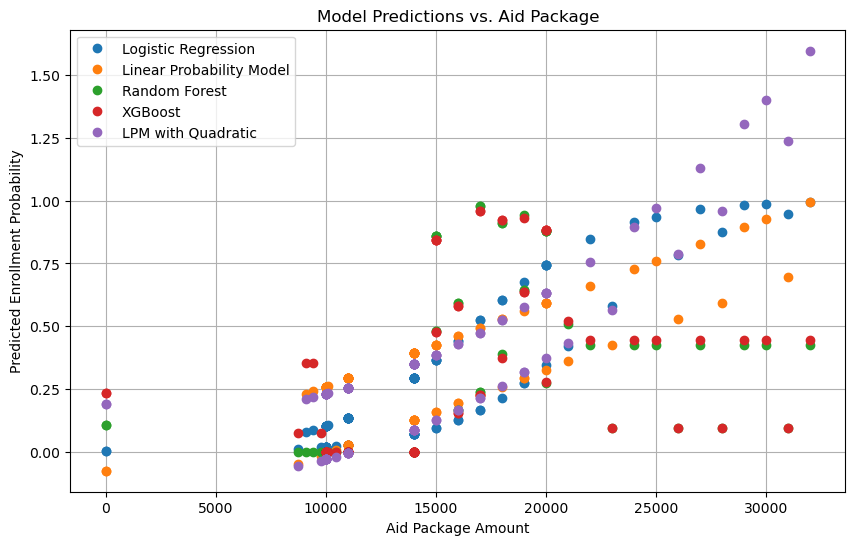

In [9]:
import matplotlib.pyplot as plt
import numpy as np

X_plot = df_predict[['Aid Package Amount', 'Visited Campus']]
plt.figure(figsize=(10, 6))

for name, result in results.items():
    model = result['model']

    # Use predict instead of predict_proba for LPMs
    if name in ['Linear Probability Model', 'LPM with Quadratic']:
        probs = model.predict(X_plot)
    else:
        probs = model.predict_proba(X_plot)[:, 1]

    plt.plot(df_predict['Aid Package Amount'], probs, label=name, marker='o', linestyle='')

plt.xlabel("Aid Package Amount")
plt.ylabel("Predicted Enrollment Probability")
plt.title("Model Predictions vs. Aid Package")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Select best model based on AUC
best_model_name = max(results, key=lambda k: results[k]['auc'])
best_model = results[best_model_name]['model']
print(f"\n✅ Best model based on AUC: {best_model_name}")


✅ Best model based on AUC: XGBoost


In [11]:
#Select best model based on MSE
best_model_name = min(results, key=lambda k: results[k]['mse'])
best_model = results[best_model_name]['model']
print(f"\n✅ Best model based on MSE: {best_model_name}")


✅ Best model based on MSE: XGBoost


In [12]:
# Select logistic regression
best_model_name = 'Logistic Regression'
best_model = results[best_model_name]['model']
print(f"\n✅ Model selected: {best_model_name}")


✅ Model selected: Logistic Regression


In [14]:
# Predict enrollment for next year's students
X_future = df_predict[['Aid Package Amount', 'Visited Campus']]
df_predict['Predicted Enrollment Probability'] = (
    best_model.predict_proba(X_future)[:, 1]
    if best_model_name != 'Linear Probability Model'
    else best_model.predict(X_future)
)
df_predict['Predicted Enrolled (Y/N)'] = np.where(df_predict['Predicted Enrollment Probability'] >= 0.5, 'Y', 'N')

# Save to new Excel file
output_path = r"C:\Users\iabaker\OneDrive - Boston University\Enrollment prediction testing\Predicted next year enrollment.xlsx"
df_predict.to_excel(output_path, index=False)
print(f"\n📁 Predictions saved to: {output_path}")



📁 Predictions saved to: C:\Users\iabaker\OneDrive - Boston University\Enrollment prediction testing\Predicted next year enrollment.xlsx


In [15]:
# Find the best way to allocate an additiona $1.8 million in financial aid
budget = 1800000
step = 1000  # Incremental aid amount to test
max_steps = 10  # Test aid increases up to 10k for each student

# Copy base data
aid_optimization = df_predict.copy()
aid_optimization['Offer This Aid Amount'] = aid_optimization['Aid Package Amount']

# Store benefit options (student_id, aid_increase, prob_gain_per_dollar)
gains = []

# Loop over students
for i, row in aid_optimization.iterrows():
    original_aid = row['Aid Package Amount']
    input_features = pd.DataFrame([[original_aid, row['Visited Campus']]], columns=['Aid Package Amount', 'Visited Campus'])

    current_prob = (
        best_model.predict_proba(input_features)[0][1]
        if best_model_name != 'Linear Probability Model'
        else best_model.predict(input_features)[0]
    )

    for s in range(1, max_steps + 1):
        new_aid = original_aid + s * step
        input_features_new = pd.DataFrame([[new_aid, row['Visited Campus']]], columns=['Aid Package Amount', 'Visited Campus'])

        new_prob = (
            best_model.predict_proba(input_features_new)[0][1]
            if best_model_name != 'Linear Probability Model'
            else best_model.predict(input_features_new)[0]
        )

        prob_gain = new_prob - current_prob
        dollars_spent = s * step

        if prob_gain > 0:
            gains.append({
                'index': i,
                'aid_increase': dollars_spent,
                'new_prob': new_prob,
                'prob_gain': prob_gain,
                'gain_per_dollar': prob_gain / dollars_spent
            })

# Sort by most efficient use of dollars
gains_sorted = sorted(gains, key=lambda x: -x['gain_per_dollar'])

# Allocate aid increases until budget is exhausted
spent = 0
for g in gains_sorted:
    i = g['index']
    added = g['aid_increase']
    if spent + added <= budget:
        aid_optimization.at[i, 'Offer This Aid Amount'] += added
        spent += added

# Round to nearest dollar
aid_optimization['Offer This Aid Amount'] = aid_optimization['Offer This Aid Amount'].round(0)

# Final file save
optimized_output_path = r"C:\Users\iabaker\OneDrive - Boston University\Enrollment prediction testing\Optimized Aid Offers.xlsx"
aid_optimization.to_excel(optimized_output_path, index=False)
print(f"🎯 Optimized aid offers saved to: {optimized_output_path}")
print(f"💰 Total aid allocated: ${aid_optimization['Offer This Aid Amount'].sum():,.0f}")

🎯 Optimized aid offers saved to: C:\Users\iabaker\OneDrive - Boston University\Enrollment prediction testing\Optimized Aid Offers.xlsx
💰 Total aid allocated: $3,248,657
